## Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for academic clarity
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
file_path = 'Tofinal/final_personal_finance_dataset_v2.csv'
df = pd.read_csv(file_path)

# Display basic info
print(f"Dataset Shape: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())

# Show first few rows
df.head()

Dataset Shape: (1044771, 12)

Column Names:
['Date', 'Transaction Description', 'Category', 'Amount', 'Type', 'UserID', 'TransactionID', 'Currency', 'Merchant', 'Account Name', 'SourceDataset', 'UnifiedCategory']


,Date,Transaction Description,Category,Amount,Type,UserID,TransactionID,Currency,Merchant,Account Name,SourceDataset,UnifiedCategory
0,2016-04-13,Bought vegetables and fruits,Groceries,9.40,Expense,US8055,TRX8_227498,NaN,NaN,NaN,unknown_transactions,Other
1,2019-01-02,Fuel purchase at local station,Motor/Travel,60.97,Expense,US8186,TRX8_759940,NaN,NaN,NaN,unknown_transactions,Transport
2,2013-11-04,Parking fee,Motor/Travel,223.55,Expense,US8114,TRX8_474070,NaN,NaN,NaN,unknown_transactions,Transport
3,2011-03-18,Household daily essentials,Groceries,8.96,Expense,US8060,TRX8_245895,NaN,NaN,NaN,unknown_transactions,Housing
4,2012-07-04,Concert or event payment,Entertainment,32.20,Expense,US8121,TRX8_512994,NaN,NaN,NaN,unknown_transactions,Entertainment


### Column Explanation
- **Date**: The date the transaction occurred.
- **Transaction Description**: Raw text describing the transaction (crucial for NLP).
- **Category**: The original category from the source system.
- **Amount**: The numeric value of the transaction.
- **Type**: Indicates if it is an 'Expense', 'Income', etc.
- **UserID**: Unique identifier for the user (simulated or real).
- **TransactionID**: Unique identifier for the specific transaction.
- **Currency**: Currency code (e.g., USD, INR).
- **Merchant**: The entity the transaction was with.
- **Account Name**: The source account (e.g., 'Credit Card', 'Bank Account').
- **SourceDataset**: Traceability to the original dataset.
- **UnifiedCategory**: The standardized category for analysis.

## Dataset Size & Coverage

In [4]:
# Compute coverage metrics
total_transactions = len(df)
unique_users = df['UserID'].nunique()
unique_categories = df['Category'].nunique()
unique_unified_categories = df['UnifiedCategory'].nunique()
num_sources = df['SourceDataset'].nunique()

print(f"Total Transactions: {total_transactions:,}")
print(f"Number of Unique Users: {unique_users}")
print(f"Number of Unique Categories (Raw): {unique_categories}")
print(f"Number of Unique Categories (Unified): {unique_unified_categories}")
print(f"Number of Source Datasets: {num_sources}")

Total Transactions: 1,044,771
Number of Unique Users: 257
Number of Unique Categories (Raw): 68
Number of Unique Categories (Unified): 12
Number of Source Datasets: 4


### Why this matters
The dataset scale ensures sufficient diversity in spending patterns. A high number of raw categories vs a lower number of unified categories confirms the need for ontological unification to make modeling feasible.

## Time Coverage Analysis

Earliest Date: 2010-01-01
Latest Date: 2025-03-30
Total Months Covered: 183


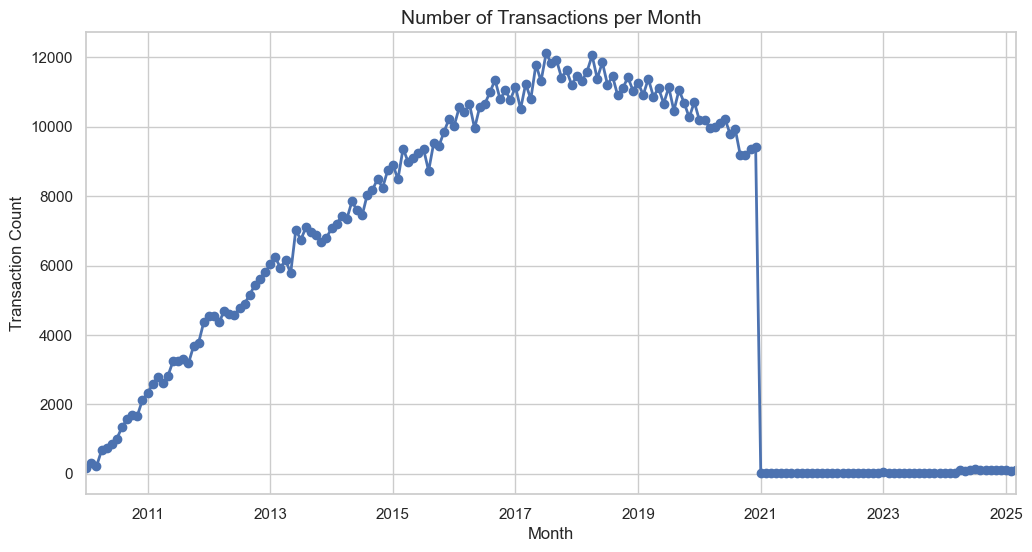

In [5]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Find range
earliest_date = df['Date'].min()
latest_date = df['Date'].max()

# Safe integer calculation for total months
total_months = (
    (latest_date.year - earliest_date.year) * 12
    + (latest_date.month - earliest_date.month)
    + 1
)

print(f"Earliest Date: {earliest_date.strftime('%Y-%m-%d')}")
print(f"Latest Date: {latest_date.strftime('%Y-%m-%d')}")
print(f"Total Months Covered: {total_months}")

# Plot transactions per month
df['MonthYear'] = df['Date'].dt.to_period('M')
monthly_counts = df['MonthYear'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o', linewidth=2)
plt.title('Number of Transactions per Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.grid(True)
plt.show()

### Impact on Behavior Baselines
The timeline coverage allows us to see if there are gaps or spikes. Consistent data over many months is ideal for training sequence models that rely on historical context.

## Missing Value Analysis

Percentage of Missing Values per Column:
Merchant                   99.537793
Currency                   99.537793
Account Name               99.537793
Transaction Description     0.043550
dtype: float64


C:\Users\Geemeth\AppData\Local\Temp\ipykernel_5468\2348817148.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_nonzero.index, y=missing_nonzero.values, palette="viridis")


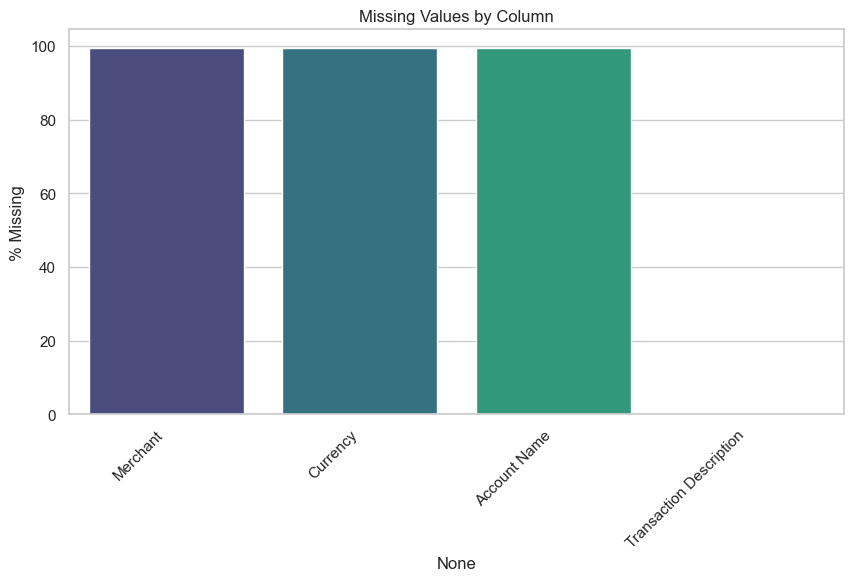

In [6]:
# Compute % missing
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = missing_percent.sort_values(ascending=False)

# Filter for non-zero missing values only to reduce noise
missing_nonzero = missing_table[missing_table > 0]

print("Percentage of Missing Values per Column:")
print(missing_nonzero)

# Visualize missingness (nonzero only)
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_nonzero.index, y=missing_nonzero.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.ylabel('% Missing')
plt.title('Missing Values by Column')
plt.show()

### Explanation
- **Critical Fields**: `Date`, `Amount`, `Transaction Description`, `UserID` should ideally be 0% missing.
- **Non-Critical**: `Merchant` or `Account Name` often come null in raw bank exports or synthetic data. This is acceptable as our models rely primarily on text descriptions and amounts.

## Transaction Type Distribution

C:\Users\Geemeth\AppData\Local\Temp\ipykernel_5468\2426127803.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette="magma")


Type
Expense    1044226
Income         545
Name: count, dtype: int64


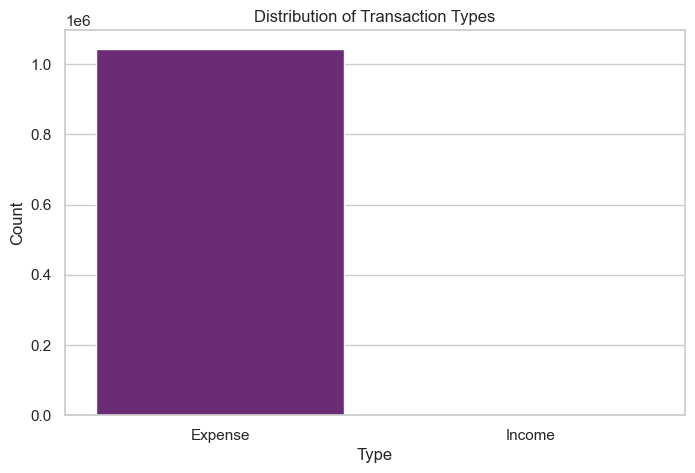

In [7]:
# Count types
type_counts = df['Type'].value_counts()

print(type_counts)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, palette="magma")
plt.title('Distribution of Transaction Types')
plt.ylabel('Count')
plt.show()

### Observation
Expenses typically dominate personal finance datasets. This is expected, as individuals make many purchases but receive income infrequently.

## Category Distribution (Raw vs Unified)

C:\Users\Geemeth\AppData\Local\Temp\ipykernel_5468\2248606748.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=raw_cat_counts.values, y=raw_cat_counts.index, ax=axes[0], palette="Blues_d")
C:\Users\Geemeth\AppData\Local\Temp\ipykernel_5468\2248606748.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unified_cat_counts.values, y=unified_cat_counts.index, ax=axes[1], palette="Greens_d")


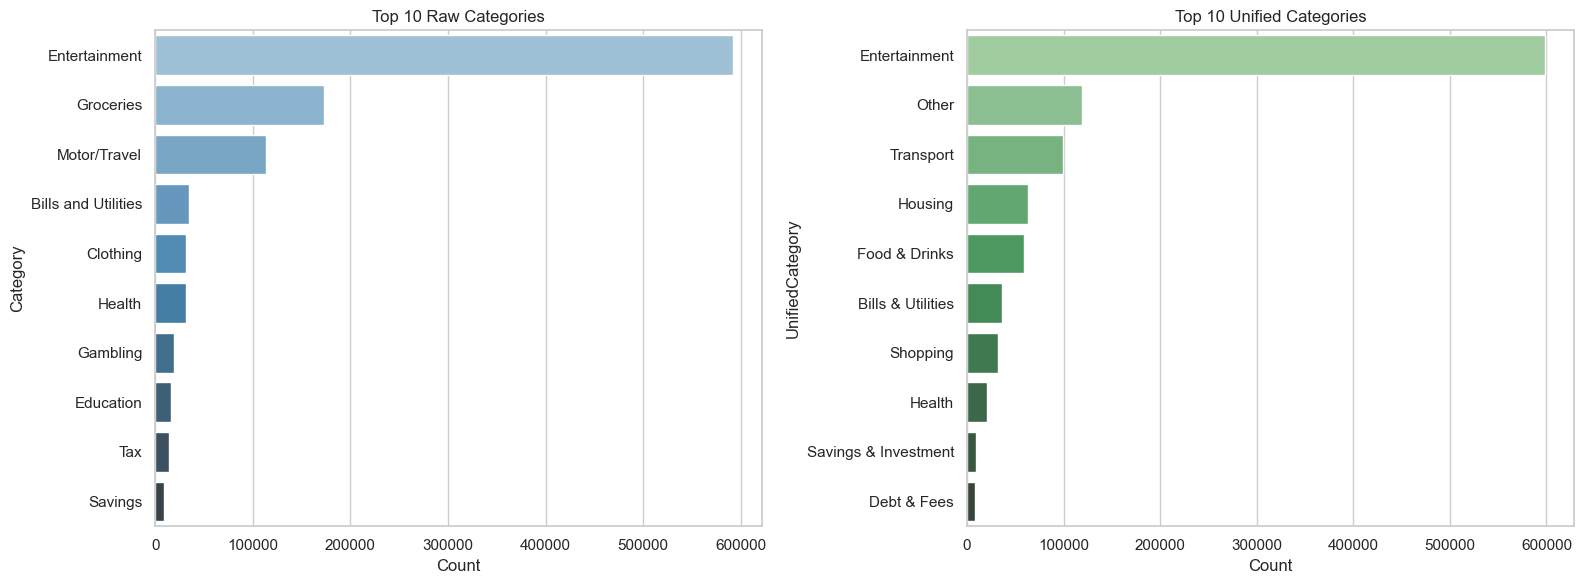

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Raw Categories
raw_cat_counts = df['Category'].value_counts().head(10)
sns.barplot(x=raw_cat_counts.values, y=raw_cat_counts.index, ax=axes[0], palette="Blues_d")
axes[0].set_title('Top 10 Raw Categories')
axes[0].set_xlabel('Count')

# Top 10 Unified Categories
unified_cat_counts = df['UnifiedCategory'].value_counts().head(10)
sns.barplot(x=unified_cat_counts.values, y=unified_cat_counts.index, ax=axes[1], palette="Greens_d")
axes[1].set_title('Top 10 Unified Categories')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Category Fragmentation
Raw categories are often messy and system-specific. The `UnifiedCategory` provides a cleaner, high-level ontology (like 'Food & Drinks', 'Housing') which is essential for consistent behavior analysis.

## Amount Distribution Analysis

Amount Summary Statistics:
count    1.044771e+06
mean     7.159617e+01
std      6.392387e+02
min      2.000000e+00
25%      1.614000e+01
50%      2.678000e+01
75%      5.215000e+01
max      2.500000e+05
Name: Amount, dtype: float64


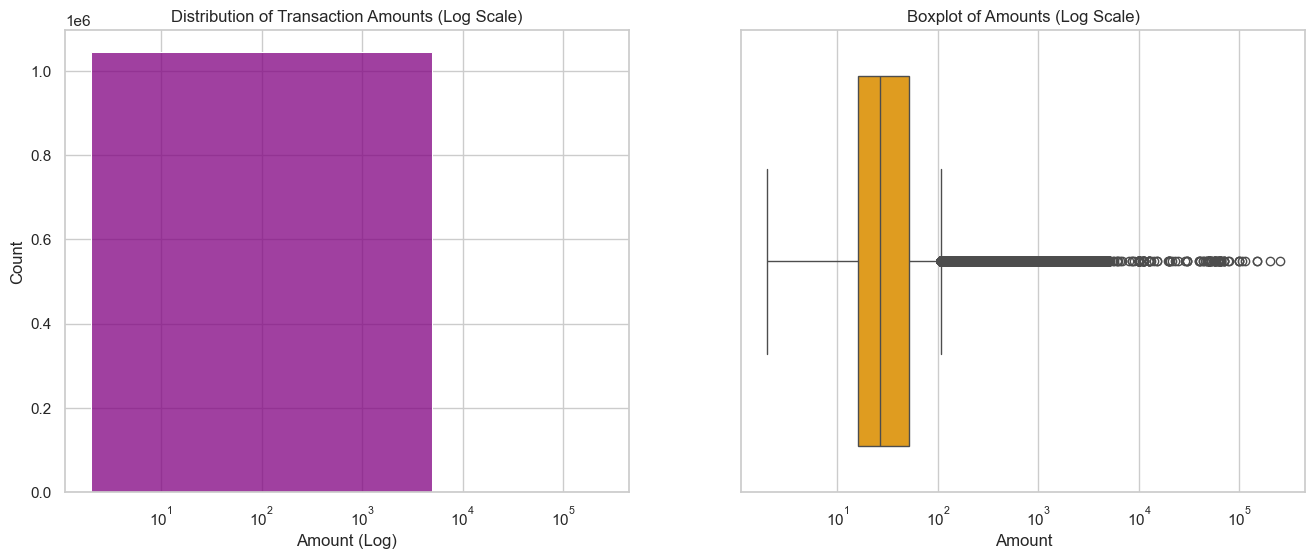

In [9]:
# Summary statistics
print("Amount Summary Statistics:")
print(df['Amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram (Log Scale - Explicitly set xscale)
sns.histplot(df['Amount'], bins=50, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Transaction Amounts (Log Scale)')
axes[0].set_xlabel('Amount (Log)')
axes[0].set_xscale('log')

# Boxplot (Log Scale - Explicitly set xscale)
sns.boxplot(x=df['Amount'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot of Amounts (Log Scale)')
axes[1].set_xscale('log')

plt.show()

### Why Log Scale?
Most transactions are small (coffee, groceries), but a few are very large (rent, electronics, salary). Averages are misleading here; the median gives a better sense of typical spending.

## User Activity Analysis

Mean Transactions per User: 4065.26
Median Transactions per User: 3904.00


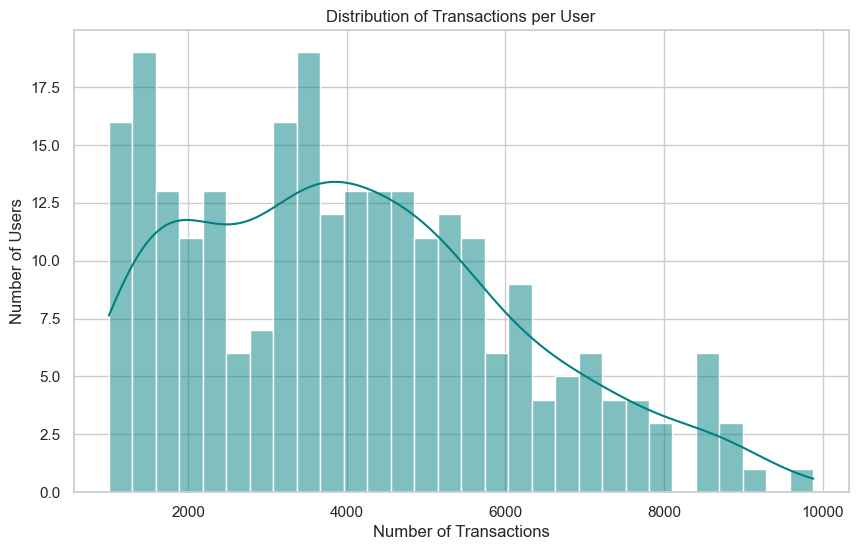

In [10]:
user_counts = df['UserID'].value_counts()

print(f"Mean Transactions per User: {user_counts.mean():.2f}")
print(f"Median Transactions per User: {user_counts.median():.2f}")

# Distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=30, kde=True, color='teal')
plt.title('Distribution of Transactions per User')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Users')
plt.show()

### Impact on Personalization
- **Heavy Users**: Good for deep learning models.
- **Light Users**: May require 'cold start' handling or simpler heuristics.

## Text Quality Analysis

Transaction Description Length Stats:
count    1.044771e+06
mean     3.329781e+00
std      5.928279e-01
min      1.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      1.900000e+01
Name: text_len, dtype: float64

Empty/Whitespace-only Descriptions: 455 (0.04%)


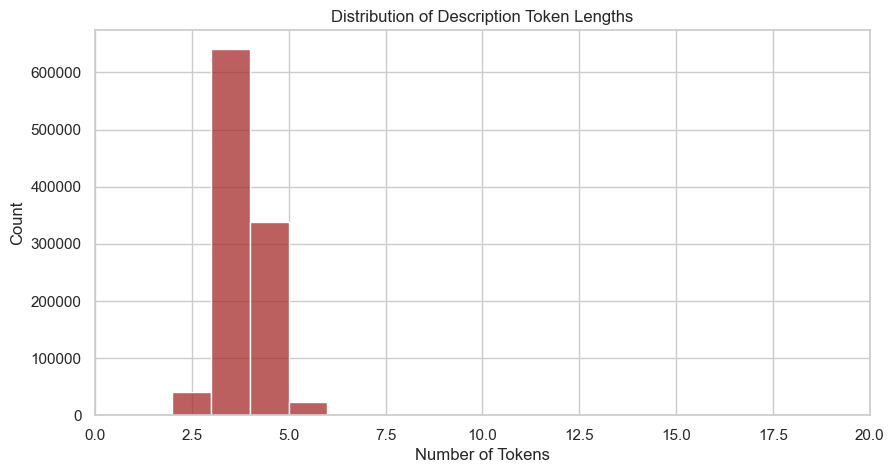

In [11]:
# Calculate text length (token count approx by split)
df['text_len'] = df['Transaction Description'].astype(str).apply(lambda x: len(x.split()))

print("Transaction Description Length Stats:")
print(df['text_len'].describe())

# % Empty or Short
# Detect purely empty or whitespace-only descriptions
empty_descs = (
    df['Transaction Description'].isnull()
    | (df['Transaction Description'].str.strip() == '')
).sum()
print(f"\nEmpty/Whitespace-only Descriptions: {empty_descs} ({empty_descs/len(df)*100:.2f}%)")

# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['text_len'], bins=20, binwidth=1, color='brown')
plt.title('Distribution of Description Token Lengths')
plt.xlabel('Number of Tokens')
plt.xlim(0, 20)
plt.show()

### Text Analysis Implication
Short descriptions (e.g., "UBER", "AMZN MKT") are common. This justifies the future need for **Hybrid TF-IDF + SBERT** embeddings to capture both keyword specificity and semantic meaning from short texts.

## Key Observations Summary

### ✅ Is the dataset suitable for behavior modeling?
- **Yes.** It covers a significant time period with diverse categories and transaction types.
- The **UnifiedCategory** column is populated, enabling consistent supervised training.

### ⚠️ Challenges Identified
- **Heavy-tailed Amounts**: Models must be robust to outliers (e.g., using log-transform).
- **Variable User History**: Some users have fewer transactions; sequence length normalization will be required in downstream temporal modeling.
- **Short Text Descriptions**: NLP models must handle sparse text features effectively.

### 🔎 Design Decisions Justified by EDA
1. **Use of SBERT**: To handle short, noisy descriptions.
2. **Log-Normalization**: For Amount features.
3. **Sequence Padding**: To standardize user history lengths for temporal models.